<a href="https://colab.research.google.com/github/Korobokkk/YADRO-2026_dsp-seminars/blob/Kiselev_5_lab/seminars/5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №5
## Основные характеристики цифровых фильтров

## Импорт библиотек

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import savgol_filter, savgol_coeffs, group_delay
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Вспомогательная функция для построения частотных характеристик
def plot_filter_response(b, a, fs=1000, title=''):
    """Строит АЧХ (линейный и дБ), ФЧХ и групповую задержку фильтра"""
    w, H = signal.freqz(b, a, fs=fs)
    mag_dB = 20*np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H))
    w_gd, gd = signal.group_delay((b, a), fs=fs)

    plt.figure(figsize=(12,10))
    plt.subplot(4,1,1)
    plt.semilogy(w, np.abs(H))
    plt.title(f'АЧХ (линейный масштаб) – {title}')
    plt.grid()
    plt.subplot(4,1,2)
    plt.plot(w, mag_dB)
    plt.title('АЧХ (дБ)')
    plt.ylabel('|H| (дБ)')
    plt.grid()
    plt.subplot(4,1,3)
    plt.plot(w, phase)
    plt.title('ФЧХ')
    plt.ylabel('Фаза (рад)')
    plt.grid()
    plt.subplot(4,1,4)
    plt.plot(w_gd, gd)
    plt.title('Групповая задержка')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Задержка (отсчёты)')
    plt.grid()
    plt.tight_layout()
    plt.show()


## Часть 1. КИХ-фильтр: скользящее среднее

**Скользящее среднее** – простейший КИХ-фильтр. Его коэффициенты: `b_k = 1/M` для `k = 0,...,M-1`. Фильтр имеет линейную фазу.

### Задание 1.1. Импульсная и переходная характеристики

Для длины окна `M = 5`:
1. Сформируйте массив коэффициентов `b` (нормированный).
2. Создайте тестовые сигналы: единичный импульс (длиной 20 отсчётов) и единичный скачок (длиной 50 отсчётов).
3. Примените фильтр с помощью `signal.lfilter(b, a, x)`, где `a = [1]`.
4. Постройте импульсную и переходную характеристики.


[0.2, 0.2, 0.2, 0.2, 0.2]


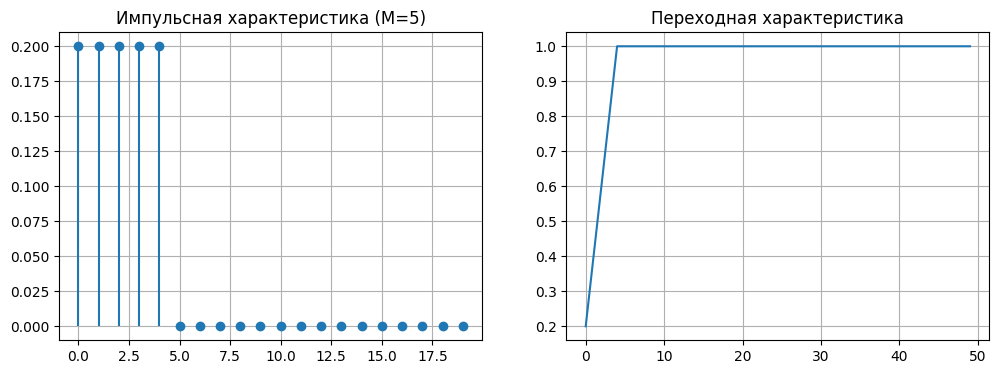

In [57]:
# Ваш код здесь
M = 5
b = []
for i in np.arange(M):
  b.append(1 / M)
a = [1]
print(b)

# Импульс
impulse = np.zeros(20)
impulse[0] = 1
# Ваш код здесь: вычислить h = signal.lfilter(...)
h = signal.lfilter(b, a, impulse)

# Скачок
step = np.ones(50)
s = signal.lfilter(b, a, step)
# Ваш код здесь: вычислить s = signal.lfilter(...)

# Построение
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(np.arange(20), h, basefmt=" ")   # Ваш код здесь: подставить h
plt.title(f'Импульсная характеристика (M={M})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(np.arange(50), s)                # Ваш код здесь: подставить s
plt.title('Переходная характеристика')
plt.grid()
plt.show()


**Вопрос:** Почему импульсная характеристика имеет конечную длину, а переходная выходит на постоянный уровень?


**Ответ:**


### Задание 1.2. АЧХ и ФЧХ

Используя функцию `plot_filter_response`, постройте характеристики для скользящего среднего с длинами окон `M = 5`, `M = 10`, `M = 20`.


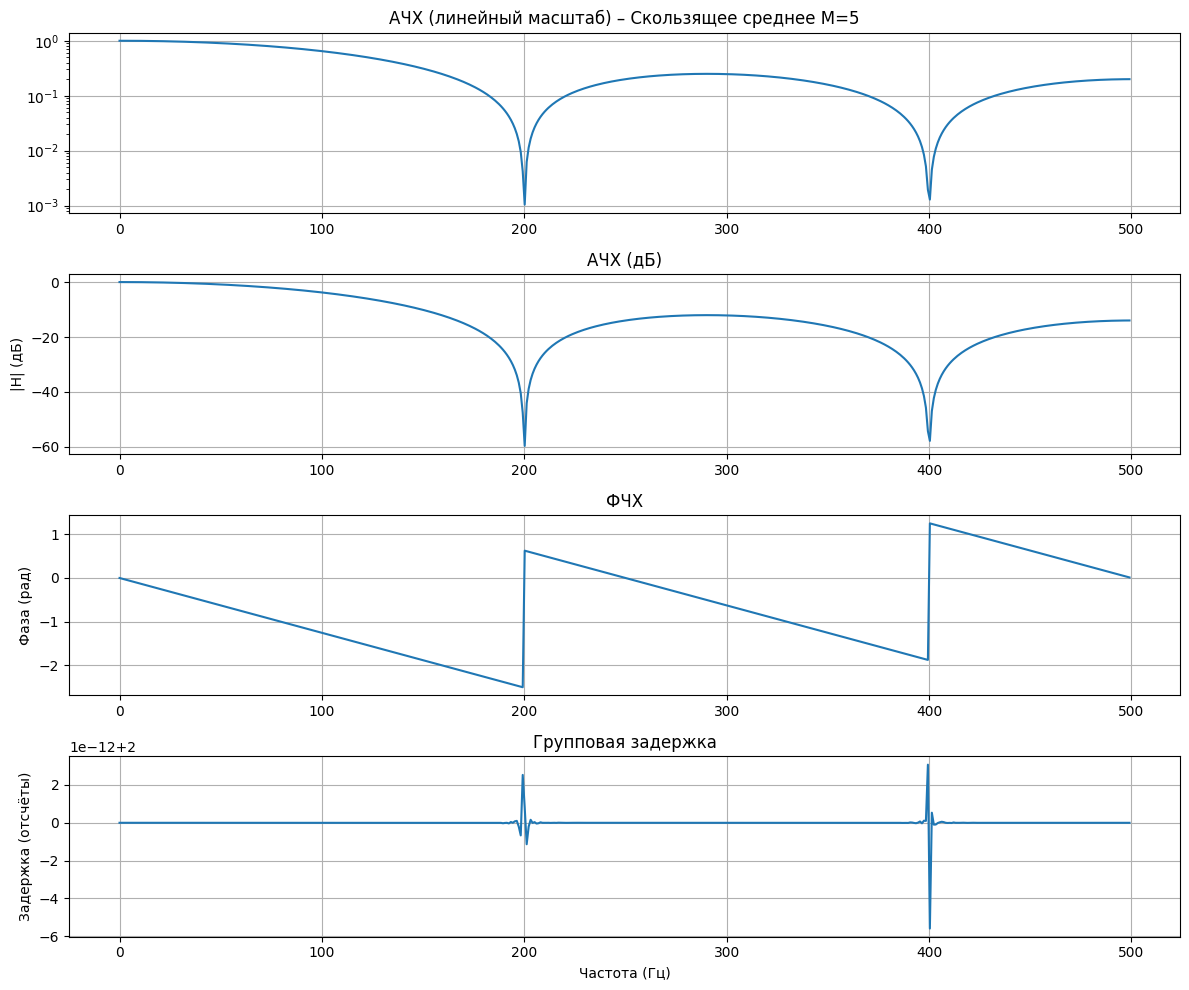

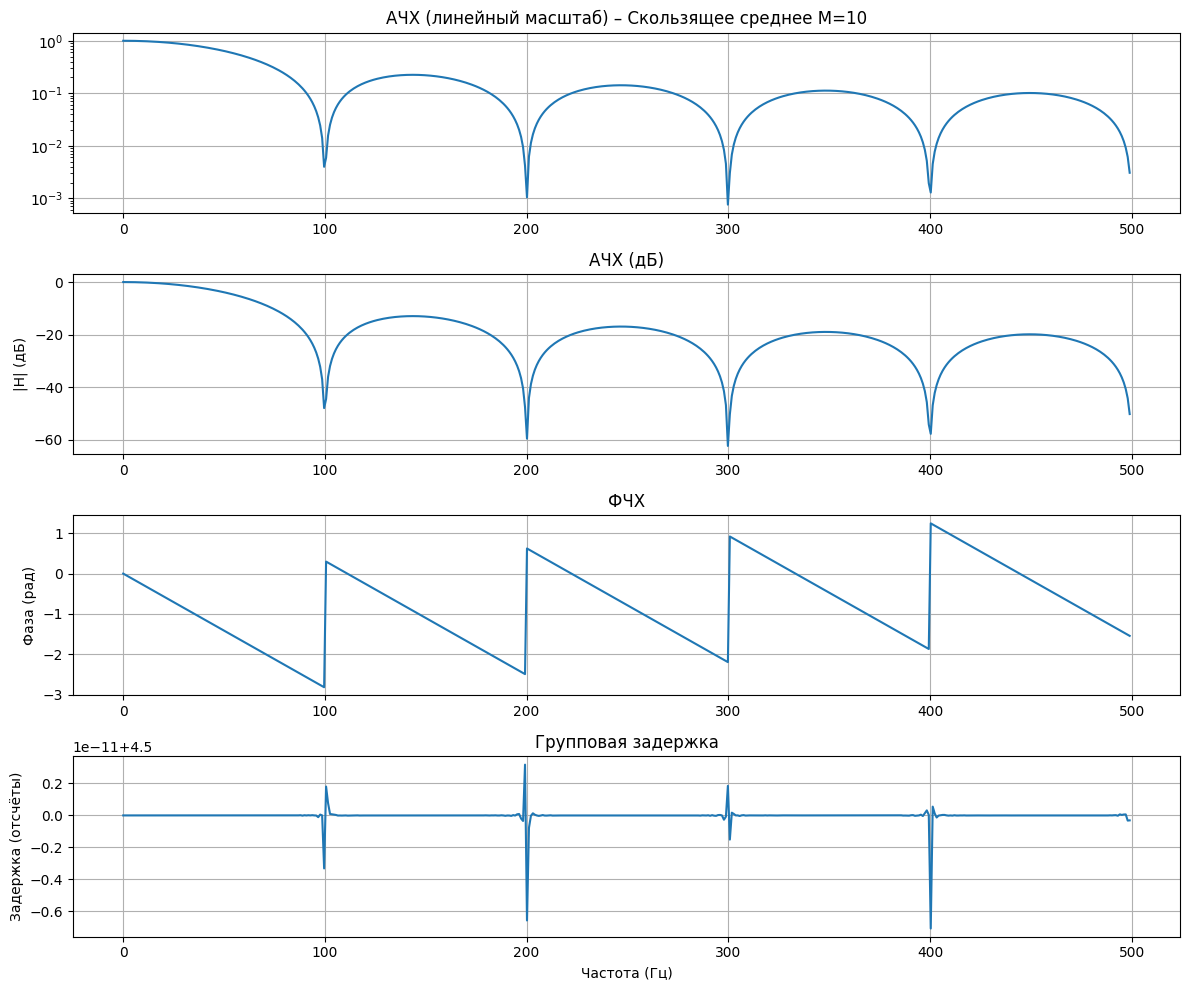

/tmp/ipykernel_2683/3306243778.py:17: UserWarning: The filter's denominator is extremely small at frequencies [1.571], around which a singularity may be present
  w_gd, gd = signal.group_delay((b, a), fs=fs)


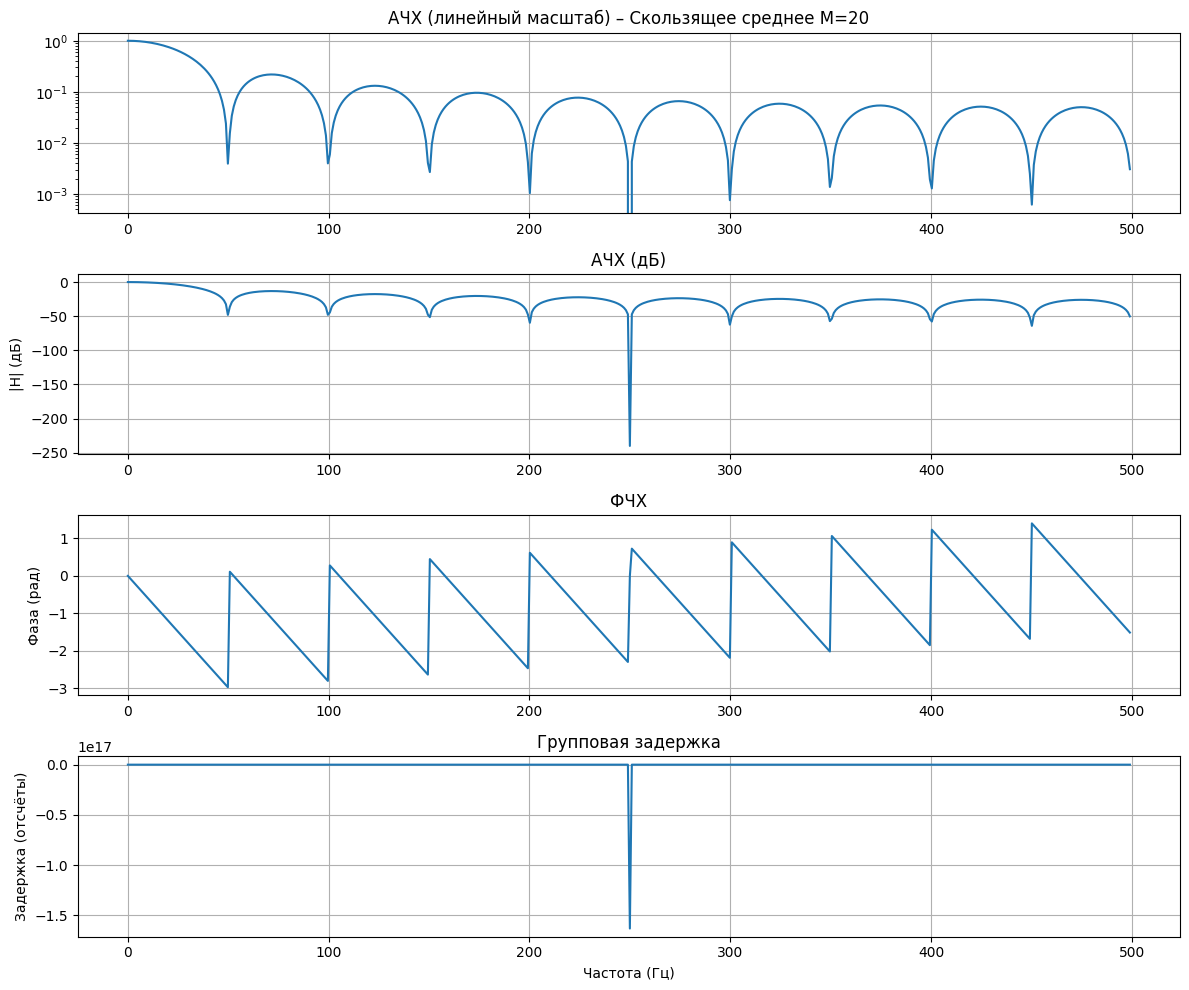

In [58]:
M_array = [5, 10, 20]

for M_idx in M_array:
  b_idx = np.ones(M_idx)/ M_idx
  plot_filter_response(b_idx, a, fs=1000, title= f'Скользящее среднее M={M_idx}')

**Вопрос:** Как изменение `M` влияет на крутизну среза АЧХ и на ФЧХ?


**Ответ:**


### Задание 1.3. Фильтрация суммы синусоид

Сгенерируйте сигнал длительностью 1 с (fs=1000 Гц): `x = sin(2π·10·t) + 0.5·sin(2π·100·t)`. Примените скользящее среднее с `M=5` и `M=20`. Постройте временные графики и спектры (амплитудный спектр через БПФ).


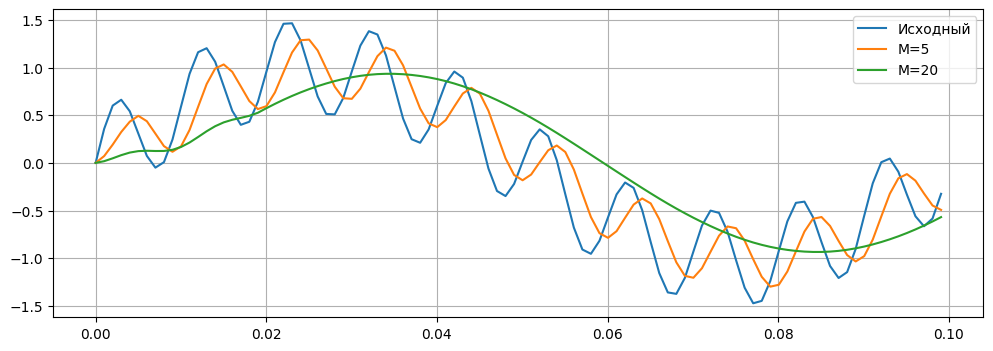

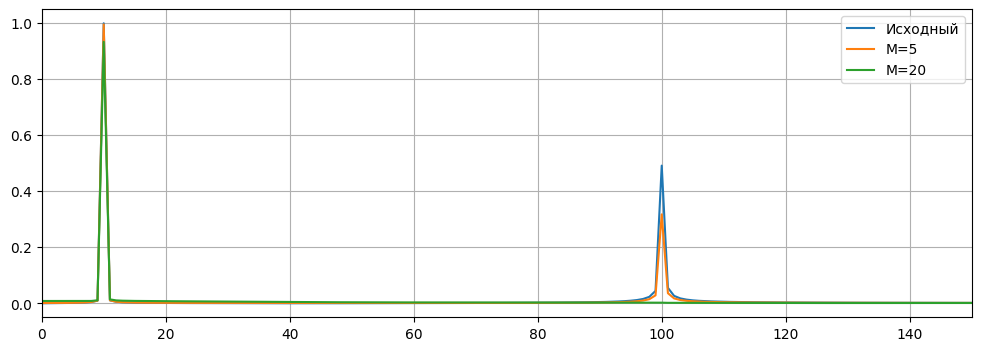

In [59]:
fs = 1000
t = np.linspace(0, 1, fs)
x = np.sin(2*np.pi*10*t) + 0.5*np.sin(2*np.pi*100*t)

b_5 = np.ones(M_array[0])/ M_array[0]
b_20 = np.ones(M_array[2])/ M_array[2]
x_5 = signal.lfilter(b_5, a, x)
x_20 = signal.lfilter(b_20, a, x)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x[:100], label='Исходный')
plt.plot(t[:100], x_5[:100], label='M=5')
plt.plot(t[:100], x_20[:100], label='M=20')
plt.legend()
plt.grid()
plt.show()

# Спектры
def plot_spectrum(s, label):
    X = np.fft.fft(s)
    freq = np.fft.fftfreq(len(s), 1/fs)
    plt.plot(freq[:len(freq)//2], np.abs(X[:len(freq)//2])/(len(s)//2), label=label)

plt.figure(figsize=(12,4))
plot_spectrum(x, 'Исходный')
plot_spectrum(x_5, 'M=5')
plot_spectrum(x_20, 'M=20')
plt.xlim(0, 150)
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Как значение `M` влияет на амплитуду 100 Гц сигнала? Объясните, почему так. Какая связь между АЧХ и результатом фильтрации?


**Ответ:**


## Часть 2. БИХ-фильтр: экспоненциальное сглаживание

Фильтр первого порядка: `y[n] = α x[n] + (1-α) y[n-1]`. Коэффициенты: `b = [α]`, `a = [1, -(1-α)]`.

### Задание 2.1. Реализация и характеристики

Для `α = 0.2`:
1. Постройте импульсную характеристику (50 отсчётов) и переходную характеристику.
2. Используя `plot_filter_response`, постройте АЧХ, ФЧХ и групповую задержку.


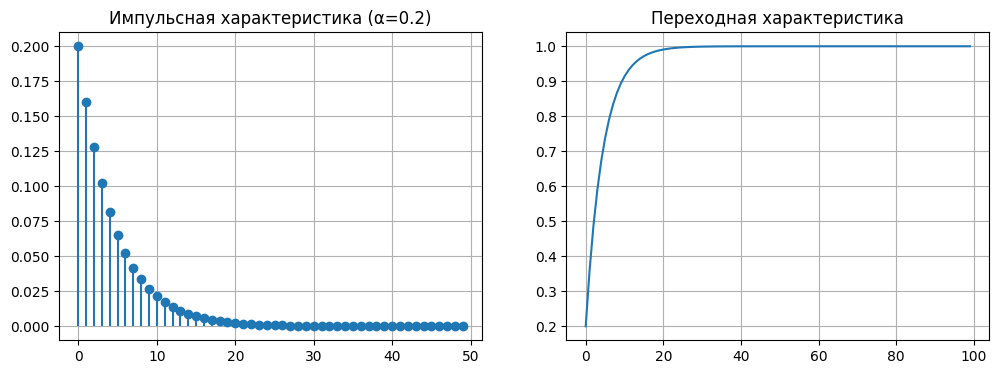

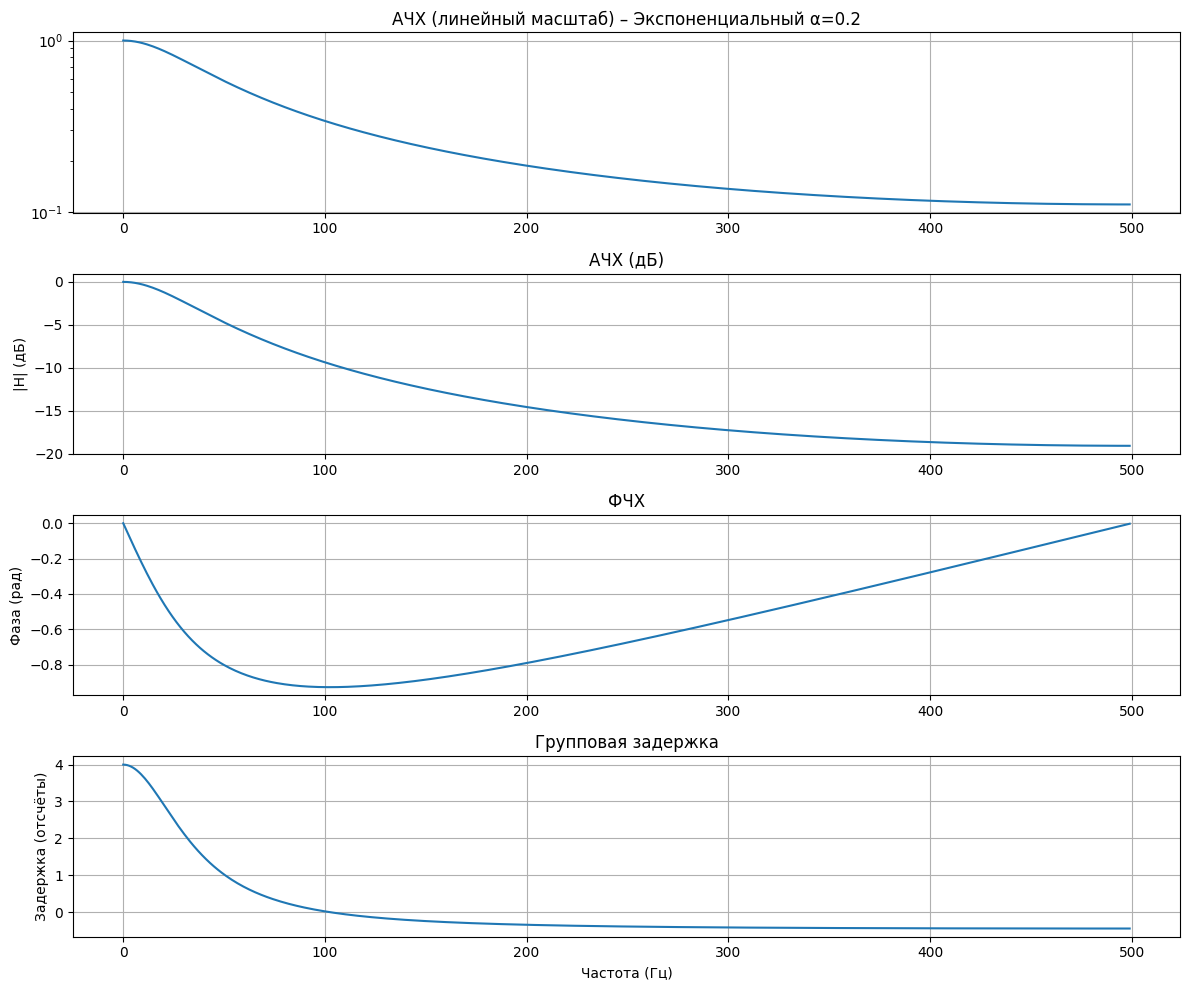

In [60]:
alpha = 0.2
b = [alpha]
a = [1, -(1-alpha)]

# Импульсная характеристика (длина 50)
impulse = np.zeros(50)
impulse[0] = 1
h = signal.lfilter(b, a, impulse)
# Переходная характеристика (длина 100)
step = np.ones(100)
s = signal.lfilter(b, a, step)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.stem(h, basefmt=" ")
plt.title(f'Импульсная характеристика (α={alpha})')
plt.grid()
plt.subplot(1,2,2)
plt.plot(s)
plt.title('Переходная характеристика')
plt.grid()
plt.show()

# Частотные характеристики
plot_filter_response(b, a, fs=1000, title=f'Экспоненциальный α={alpha}')


### Задание 2.2. Влияние параметра α

Исследуйте фильтр при `α = 0.05, 0.2, 0.8`. Постройте на одном графике АЧХ (в дБ) и на другом – групповую задержку. Сделайте выводы.


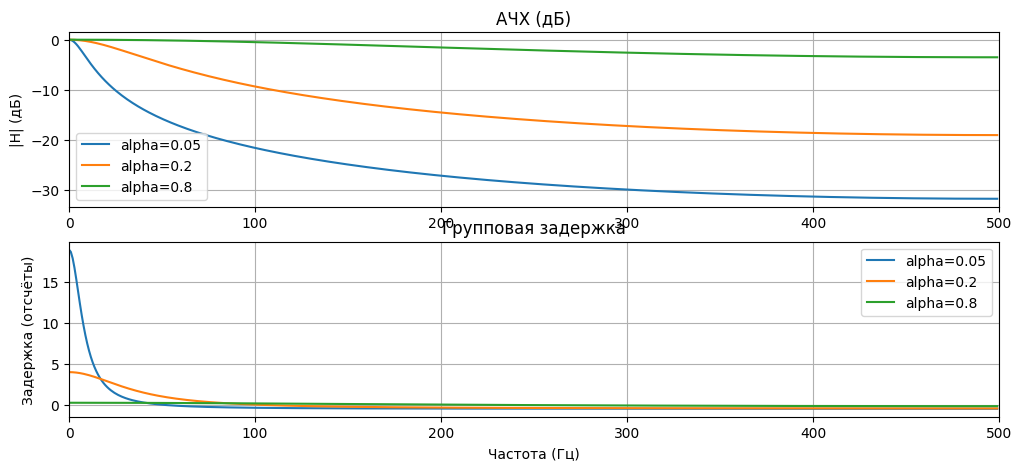

In [61]:
alphas = [0.05, 0.2, 0.8]

for alphas_value in alphas:
  b = [alphas_value]
  a = [1, -(1 - alphas_value)]

  w, H = signal.freqz(b, a, fs=fs)
  mag_dB = 20*np.log10(np.abs(H) + 1e-12)
  phase = np.unwrap(np.angle(H))
  w_gd, gd = signal.group_delay((b, a), fs=fs)

  plt.subplot(2,1,1)
  plt.plot(w, mag_dB, label = f'alpha={alphas_value}')
  plt.subplot(2,1,2)
  plt.plot(w_gd, gd, label = f'alpha={alphas_value}')

plt.subplot(2,1,1)
plt.title('АЧХ(в дБ)')
plt.title('АЧХ (дБ)')
plt.ylabel('|H| (дБ)')
plt.xlim(0,500)
plt.grid()
plt.legend()

plt.subplot(2,1,2)
plt.title('Групповая задержка')
plt.xlabel('Частота (Гц)')
plt.ylabel('Задержка (отсчёты)')
plt.xlim(0,500)
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как α влияет на скорость реакции фильтра на изменение сигнала и на крутизну спада АЧХ?


**Ответ:**


### Задание 2.3. Фильтрация зашумлённого сигнала

Сгенерируйте сигнал: синусоида 20 Гц + белый шум (SNR ≈ 5 дБ), fs=500 Гц. Примените экспоненциальный фильтр с α = 0.1 и α = 0.5. Постройте исходный и отфильтрованные сигналы (первые 0.2 с). Сравните степень сглаживания и задержку.


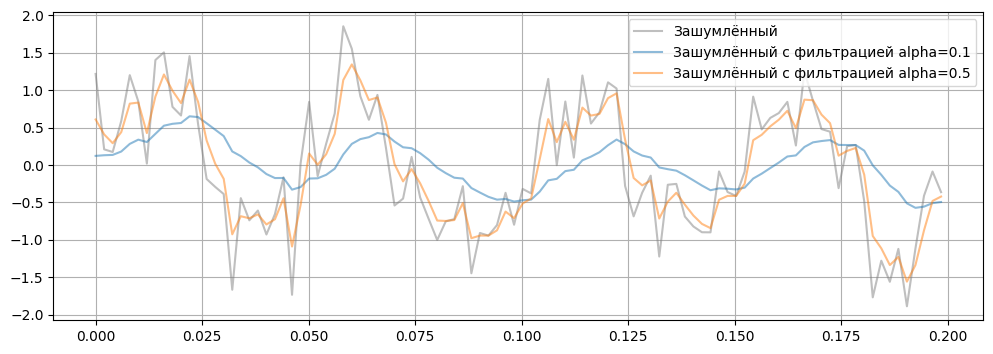

In [62]:
fs = 500
t = np.linspace(0, 1, fs)
x_clean = np.sin(2*np.pi*20*t)
noise = 0.5 * np.random.randn(len(t))
x_noisy = x_clean + noise

alphas = [0.1, 0.5]
b_0 = [alphas[0]]
a_0 = [1, -(1 - alphas[0])]
b_1 = [alphas[1]]
a_1 = [1, -(1 - alphas[1])]

x_noisy_and_filt_0 = signal.lfilter(b_0, a_0, x_noisy)
x_noisy_and_filt_1 = signal.lfilter(b_1, a_1, x_noisy)

plt.figure(figsize=(12,4))
plt.plot(t[:100], x_noisy[:100], 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(t[:100], x_noisy_and_filt_0[:100], alpha=0.5, label=f'Зашумлённый c фильтрацией alpha={alphas[0]}')
plt.plot(t[:100], x_noisy_and_filt_1[:100], alpha=0.5, label=f'Зашумлённый c фильтрацией alpha={alphas[1]}')
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Как на временных графиках проявляется групповая задержка, вносимая БИХ-фильтром?


**Ответ:**


## Часть 3. Фильтр Савицкого – Голея (Savitzky–Golay)

Этот КИХ-фильтр основан на локальной полиномиальной регрессии. Он сохраняет форму сигнала (пики, перегибы) лучше, чем скользящее среднее.

### Задание 3.1. Базовое применение и влияние параметров

Сгенерируйте синусоиду 5 Гц (fs=100 Гц, длительность 2 с) и добавьте белый шум (дисперсия 0.2). Примените `savgol_filter` с параметрами:
- (window=11, polyorder=2)
- (window=21, polyorder=2)
- (window=11, polyorder=5)

Постройте исходный чистый сигнал, зашумлённый и три сглаженные версии. Объясните влияние параметров.


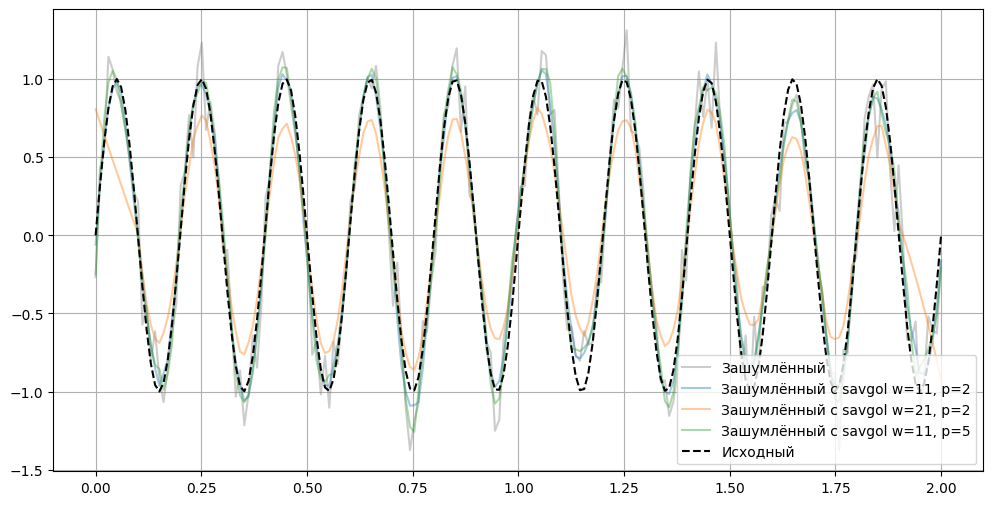

In [63]:
fs = 100
t = np.linspace(0, 2, 2*fs)
x_clean = np.sin(2*np.pi*5*t)
noise = 0.2 * np.random.randn(len(t))
x_noisy = x_clean + noise

# Ваш код здесь: применить savgol_filter с разными параметрами
s_1 = savgol_filter(x_noisy, window_length=11, polyorder=2)
s_2 = savgol_filter(x_noisy, window_length=21, polyorder=2)
s_3 = savgol_filter(x_noisy, window_length=11, polyorder=5)


plt.figure(figsize=(12,6))
plt.plot(t, x_noisy, 'gray', alpha=0.4, label='Зашумлённый')
plt.plot(t, s_1, alpha=0.4, label='Зашумлённый c savgol w=11, p=2')
plt.plot(t, s_2, alpha=0.4, label='Зашумлённый c savgol w=21, p=2')
plt.plot(t, s_3, alpha=0.4, label='Зашумлённый c savgol w=11, p=5')
plt.plot(t, x_clean, 'k--', label='Исходный')
# Ваш код здесь: добавить графики y1, y2, y3
plt.legend()
plt.grid()
plt.show()


**Вопрос 3.1:** Как увеличение `window_length` и увеличение `polyorder` влияют на степень сглаживания и сохранение формы сигнала?


**Ответ:**


### Задание 3.2. Сравнение со скользящим средним

Создайте сигнал с острым пиком (гауссов импульс с σ=3) на фоне шума. Примените скользящее среднее (window=11) и Savitzky–Golay (window=11, polyorder=2). Сравните, какой фильтр лучше сохраняет форму пика.


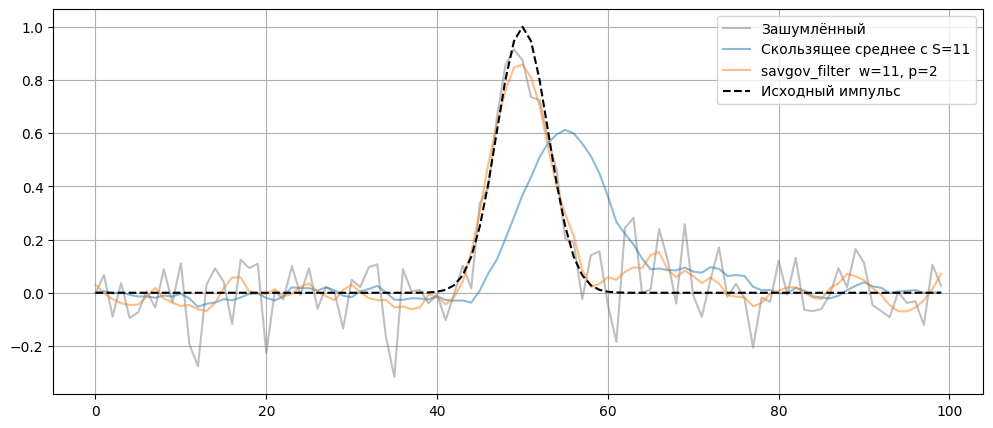

In [68]:
# Генерация гауссова импульса
N = 100
x_pulse = np.zeros(N)
x_pulse[N//2] = 1
sigma = 3
gaussian = np.exp(-(np.arange(N)-N//2)**2/(2*sigma**2))
x_clean_pulse = gaussian / np.max(gaussian)
noise_pulse = 0.1 * np.random.randn(N)
x_noisy_pulse = x_clean_pulse + noise_pulse

b = np.ones(11) / 11
a= [1]
filtered_signal  = signal.lfilter(b, a, x_noisy_pulse)
savgol_signal = savgol_filter(x_noisy_pulse, window_length=11, polyorder=2)


plt.figure(figsize=(12,5))
plt.plot(x_noisy_pulse, 'gray', alpha=0.5, label='Зашумлённый')
plt.plot(filtered_signal , alpha=0.5, label='Скользящее среднее с S=11')
plt.plot(savgol_signal, alpha=0.5, label='savgov_filter  w=11, p=2')
plt.plot(x_clean_pulse, 'k--', label='Исходный импульс')
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Какой из фильтров лучше сохраняет пик?


**Ответ:**


### Задание 3.3. Частотные характеристики

Получите коэффициенты Savitzky–Golay для `window_length=11, polyorder=2` с помощью `savgol_coeffs`. Нормируйте их так, чтобы сумма была равна 1. Постройте АЧХ этого фильтра и сравните с АЧХ скользящего среднего той же длины.


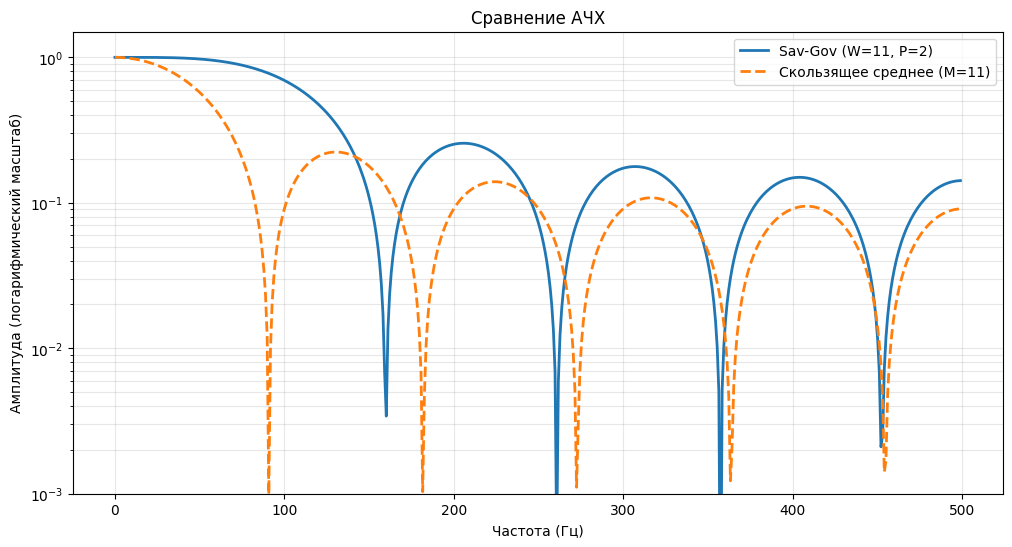

In [71]:
window_length = 11
polyorder = 2
coeffs = savgol_coeffs(window_length, polyorder)
coeffs = coeffs / np.sum(coeffs)   # нормировка


coeffs_sg = savgol_coeffs(window_length, polyorder)
coeffs_sg = coeffs_sg / np.sum(coeffs_sg)
coeffs_ma = np.ones(window_length) / window_length
w_sg, h_sg = signal.freqz(coeffs_sg, [1], fs=1000)
w_ma, h_ma = signal.freqz(coeffs_ma, [1], fs=1000)

#  Построение
plt.figure(figsize=(12, 6))
plt.semilogy(w_sg, np.abs(h_sg), label=f'Sav-Gov (W={window_length}, P={polyorder})', lw=2)
plt.semilogy(w_ma, np.abs(h_ma), label=f'Скользящее среднее (M={window_length})', lw=2, linestyle='--')

plt.title('Сравнение АЧХ')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда (логарифмический масштаб)')
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.ylim(1e-3, 1.5)
plt.show()

# Ваш код здесь: вычислить АЧХ через freqz для coeffs и для скользящего среднего

# Построить на одном графике (логарифмический масштаб)


**Вопрос:** Чем отличается АЧХ Savitzky–Golay от АЧХ скользящего среднего? Как это объясняет сохранение формы сигнала?


**Ответ:**


### Задание 3.4. Фильтрация меандра

Сгенерируйте меандр частотой 2 Гц (fs=500 Гц) и добавьте синусоидальную помеху 50 Гц амплитудой 0.5. Примените Savitzky–Golay (window=15, polyorder=3) и скользящее среднее (window=15). Сравните, как подавляется помеха и сохраняются фронты.


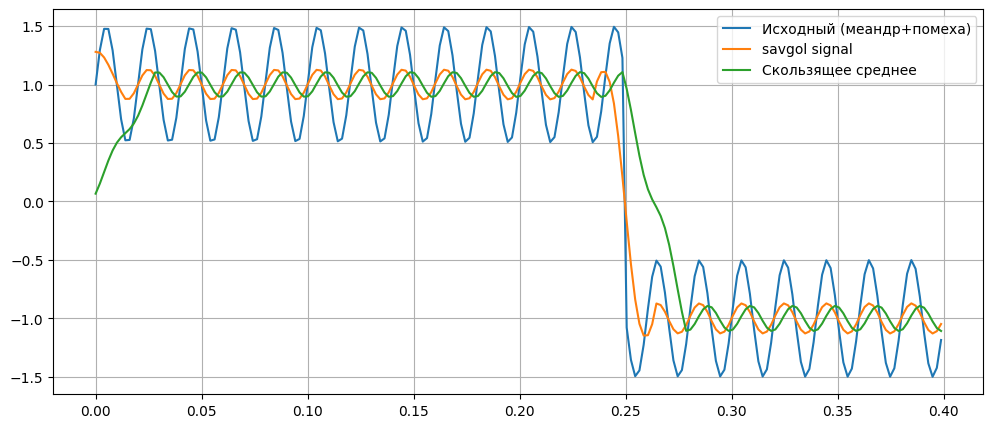

In [73]:
fs = 500
t = np.linspace(0, 1, fs)
meander = signal.square(2*np.pi*2*t)
interference = 0.5 * np.sin(2*np.pi*50*t)
x_meander = meander + interference

new_savgol_signal = savgol_filter(x_meander, window_length=15, polyorder=3)
b= np.ones(15) / 15
signal_s_avg = signal.lfilter(b, [1], x_meander)


plt.figure(figsize=(12,5))
plt.plot(t[:200], x_meander[:200], label='Исходный (меандр+помеха)')
plt.plot(t[:200], new_savgol_signal[:200], label='savgol signal')
plt.plot(t[:200], signal_s_avg[:200], label='Скользящее среднее')
plt.legend()
plt.grid()
plt.show()


**Вопрос:** Какой фильтр лучше подходит для обработки сигналов с резкими фронтами? Почему?


**Ответ:**


## Часть 4. Сравнение КИХ и БИХ фильтров

Для скользящего среднего (`M=10`), экспоненциального фильтра (`α=0.2`) и Savitzky–Golay (`win=11, polyorder=2`):

1. Постройте на одном графике их АЧХ (в дБ) и групповую задержку.
2. Подайте на них единичный импульс и единичный скачок, постройте реакции.
3. Сгенерируйте сигнал из прямоугольных импульсов с шумом (как в примере ниже) и примените все три фильтра. Оцените качество подавления шума и сохранения фронтов.


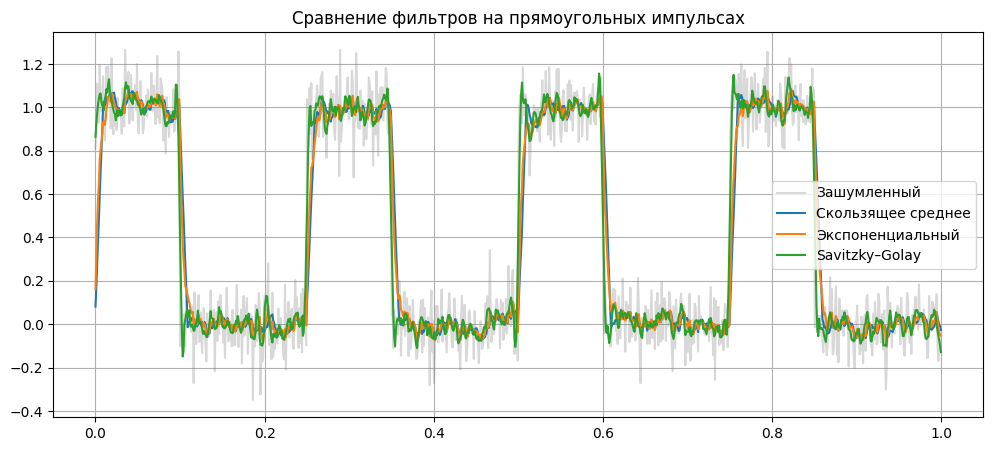

In [79]:
# Сигнал с прямоугольными импульсами
fs = 1000
t = np.linspace(0, 1, fs)
pulse_train = np.zeros_like(t)
pulse_train[0:100] = 1
pulse_train[250:350] = 1
pulse_train[500:600] = 1
pulse_train[750:850] = 1
noise = 0.1 * np.random.randn(len(t))
x_pulse_noisy = pulse_train + noise

M = 10
alpha = 0.2
win = 11
pol = 2

# 1
b = np.ones(M)/M
a = [1]
s_avg = signal.lfilter(b, a, x_pulse_noisy)
# exp filt
b = [alpha]
a = [1, -(1 - alpha)]
s_exp = signal.lfilter(b, a, x_pulse_noisy)
# savgol
s_savgol= savgol_filter(x_pulse_noisy, window_length=win, polyorder=pol)


plt.plot(t, x_pulse_noisy, color='gray', alpha=0.3, label='Зашумленный')

plt.plot(t, s_avg, label='Скользящее среднее')
plt.plot(t, s_exp, label='Экспоненциальный')
plt.plot(t, s_savgol, label='Savitzky–Golay')

plt.title('Сравнение фильтров на прямоугольных импульсах')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Какой фильтр обеспечивает наилучшее подавление шума? Какой лучше сохраняет фронты? Какой имеет наименьшие фазовые искажения?


**Ответ:**
